## K近邻分类练习题

在这个练习中，我们使用电信企业的客户流失数据集，Orange_Telecom_Churn_Data.csv（存放在当前目录下）。我们先读入数据集，做一些数据预处理，然后使用K近邻模型根据用户的特点来预测其是否会流失。

### 第一步：
* 将数据集读入变量data中，并查看其前5行。
* 去除其中的“state"，"area_code"和"phone_number"三列。

In [7]:
# 将数据集读入变量data中，并查看其前5行
import pandas as pd

# 将数据集读入变量data中
data = pd.read_csv('Orange_Telecom_Churn_Data.csv')

# 查看前5行（可选，用于检查）
print(data.head(5))

  state  account_length  area_code phone_number intl_plan voice_mail_plan  \
0    KS             128        415     382-4657        no             yes   
1    OH             107        415     371-7191        no             yes   
2    NJ             137        415     358-1921        no              no   
3    OH              84        408     375-9999       yes              no   
4    OK              75        415     330-6626       yes              no   

   number_vmail_messages  total_day_minutes  total_day_calls  \
0                     25              265.1              110   
1                     26              161.6              123   
2                      0              243.4              114   
3                      0              299.4               71   
4                      0              166.7              113   

   total_day_charge  ...  total_eve_calls  total_eve_charge  \
0             45.07  ...               99             16.78   
1             27.47  ...  

In [8]:
# 去除“state"，"area_code"和"phone_number"三列
data = data.drop(columns=['state', 'area_code', 'phone_number'])

### 第二步：
* 有些列的值是分类数据，如'intl_plan', 'voice_mail_plan', 'churned'这三列，需要把它们转换成数值数据。

In [9]:
from sklearn.preprocessing import LabelBinarizer

lb = LabelBinarizer()

for col in ['intl_plan', 'voice_mail_plan', 'churned']:
    data[col] = lb.fit_transform(data[col])
data.head(5)

,account_length,intl_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,number_customer_service_calls,churned
0,128,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,107,0,1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,137,0,0,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
3,84,1,0,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0
4,75,1,0,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0


### 第三步：
* 将除“churned”列之外的所有其他列的数据与“churned”列的数据分开，即创建两张数据表，X_data和y_data。
* 使用课件中提到的某种尺度转换方法（scaling method）来缩放X_data。

In [10]:
# 生成X_data和y_data
from sklearn.preprocessing import StandardScaler
X_data = data.drop(columns=['churned'])
y_data = data['churned']

In [11]:
# 缩放X_data
scaler = StandardScaler()
X_data_scaled = scaler.fit_transform(X_data)

### 第四步：
* 创建一个k=3的K近邻模型，并拟合X_data和y_data。

In [12]:
# 创建一个3NN模型，并训练
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=3)

# 拟合（训练）模型
knn_model.fit(X_data_scaled, y_data)

KNeighborsClassifier(n_neighbors=3)

### 第五步：
* 用上一步训练好的K近邻模型预测相同的数据集，即X_data，并评测预测结果的精度。

In [13]:
# 预测并评价
from sklearn.metrics import accuracy_score

# 预测相同的数据集
y_pred = knn_model.predict(X_data_scaled)

# 评测预测结果的精度
accuracy_k3 = accuracy_score(y_data, y_pred)
print(f"K=3 模型的预测精度: {accuracy_k3:.4f}")

K=3 模型的预测精度: 0.9396


### 第六步：
* 构建一个同样是`n_neighbors=3`的模型，但是用距离作为聚集K个近邻预测结果的权重。同样计算此模型在X_data上的预测精度。 
* 构建另一个K近邻模型：使用均匀分布的权重，但是将闵科夫斯基距离中的指数参数设为1(`p=1`)，即使用曼哈顿距离。

In [14]:
# n_neighbors=3, weights='distance'
# 模型 A: 使用距离作为权重 (weights='distance')
knn_dist_weight = KNeighborsClassifier(n_neighbors=3, weights='distance')
knn_dist_weight.fit(X_data_scaled, y_data)
acc_dist_weight = accuracy_score(y_data, knn_dist_weight.predict(X_data_scaled))
print(f"K=3, 距离加权模型的精度: {acc_dist_weight:.4f}")


K=3, 距离加权模型的精度: 1.0000


In [15]:
# n_neighbors=3, p=1
knn_manhattan = KNeighborsClassifier(n_neighbors=3, p=1)
knn_manhattan.fit(X_data_scaled, y_data)
acc_manhattan = accuracy_score(y_data, knn_manhattan.predict(X_data_scaled))
print(f"K=3, 曼哈顿距离模型的精度: {acc_manhattan:.4f}")

K=3, 曼哈顿距离模型的精度: 0.9416


### 第七步：
* 将K值从1变化到20，训练20个不同的K近邻模型。权重使用均匀分布的权重（缺省的）。闵科夫斯基距离的指数参数(`p`)可以设为1或者2（只要一致即可）。将每个模型得到的精度和其`k`值存到一个列表或字典中。
* 将`accuracy`和`k`的关系绘成图表。当`k=1`时，你观察到了什么? 为什么?

In [16]:
import matplotlib.pyplot as plt

k_values = range(1, 21)
accuracies = []

# 遍历不同的K值
for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k, p=2) # p=2为欧氏距离，保持一致
    model.fit(X_data_scaled, y_data)
    acc = accuracy_score(y_data, model.predict(X_data_scaled))
    accuracies.append(acc)

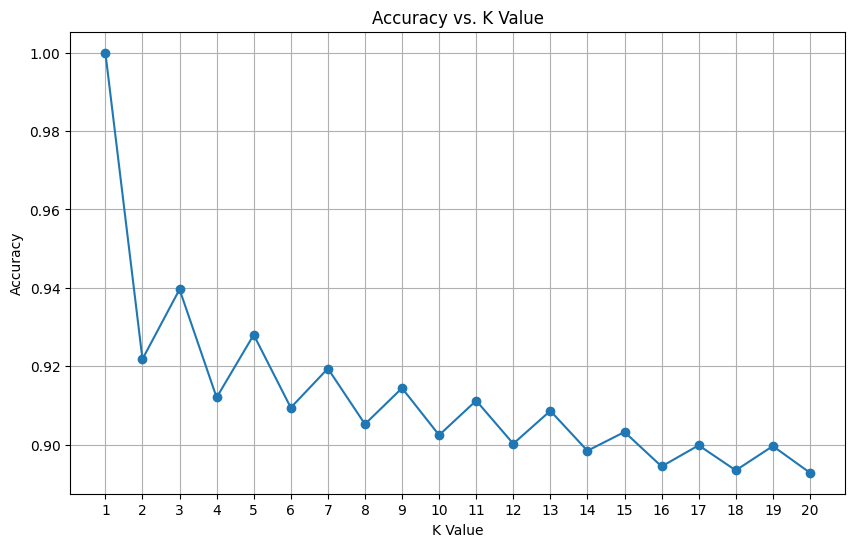

In [17]:
# 绘制图表
plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, marker='o', linestyle='-')
plt.title('Accuracy vs. K Value')
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.xticks(k_values)
plt.grid(True)
plt.show()